# 2 — Registration methods compared

`reg1d` currently implements two linear and four nonlinear registration methods, all callable
through the same interface and all returning a `RegistrationResult`:

| function | type | warp family |
|---|---|---|
| `register_linear` | linear | interpolation to a common grid (temporal normalisation) |
| `register_shift` | linear | γ(t) = t + δ |
| `register_affine` | linear | γ(t) = a t + b |
| `register_srsf` | nonlinear | elastic (SRSF / Fisher–Rao), dynamic programming |
| `register_dtw` | nonlinear | dynamic time warping (step patterns, optional window) |
| `register_landmark` | nonlinear | monotone interpolant through landmarks |
| `register_continuous` | nonlinear | smooth parametric γ = ∫exp(W), penalised least squares |
| `register_sim` | nonlinear | self-modelling / shape-invariant model (amplitude + smooth warp) |
| `register_pairwise` | nonlinear | pairwise synchronisation (template-free) |
| `register_bayes` | nonlinear | Bayesian registration (posterior samples of the warps) — see notebook *Bayesian-vs-nlreg1d* |

This notebook applies each of them to the `Dorn2012` dataset and comments on their suitability.
All functions return a `RegistrationResult` (`LinearRegistrationResult` or
`NonlinearRegistrationResult`; `result.islinear` tells which).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # so that this notebook finds reg1d without installation
import numpy as np
from matplotlib import pyplot as plt
import reg1d
print('reg1d version:', reg1d.__version__)

reg1d version: 0.0.2


In [2]:
dataset = reg1d.data.Dorn2012()
speed   = dataset.group     # running speed code (0-3)
y       = dataset.y         # object array: 8 observations, 185-383 frames each
print(dataset)

def plot_Dorn2012(y, xlabel='Frame number', ylabel='Anterioposterior GRF (N)', title=None, ax=None):
    ax = plt.axes() if ax is None else ax
    reg1d.plot.plot_curves(y, group=speed, ax=ax, colors=['k','b','g','r'],
                           x=None if xlabel.startswith('Frame') else 'percent',
                           labels=[f'Speed = {i}' for i in range(4)])
    ax.axhline(0, color='k', ls=':')
    ax.set_xlabel(xlabel, size=12)
    ax.set_ylabel(ylabel, size=12)
    if title is not None:
        ax.set_title(title, size=14)
    return ax

yi = reg1d.register_linear(y, n=101).y

Dataset: Dorn2012
    J       = 8
    lengths = [365, 383, 299, 299, 232, 238, 185, 185]
    groups  = [0, 1, 2, 3]



## Linear methods

Shift and affine registration translate (and, for affine, uniformly stretch) each observation in
time to best match the cross-sectional mean, with a few Procrustes iterations. Values needed from
outside the original domain are held at the boundary value. These methods can only correct
*global* timing differences; they cannot align features that move in opposite directions.

shifts (fraction of stance): [-0.006 -0.013 -0.01  -0.008  0.007  0.001  0.002  0.027]
affine (a, b):
[[ 1.008 -0.016]
 [ 0.817  0.109]
 [ 1.036 -0.031]
 [ 1.02  -0.024]
 [ 1.029 -0.011]
 [ 1.023 -0.015]
 [ 1.027 -0.015]
 [ 1.039  0.002]]


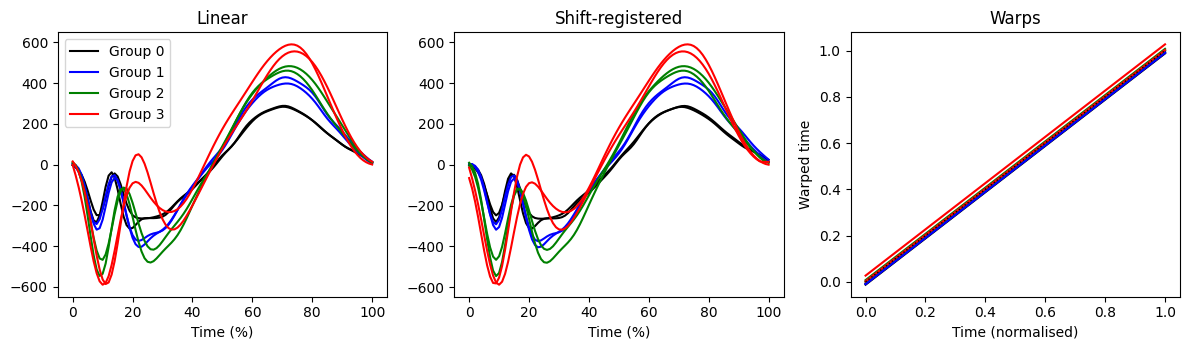

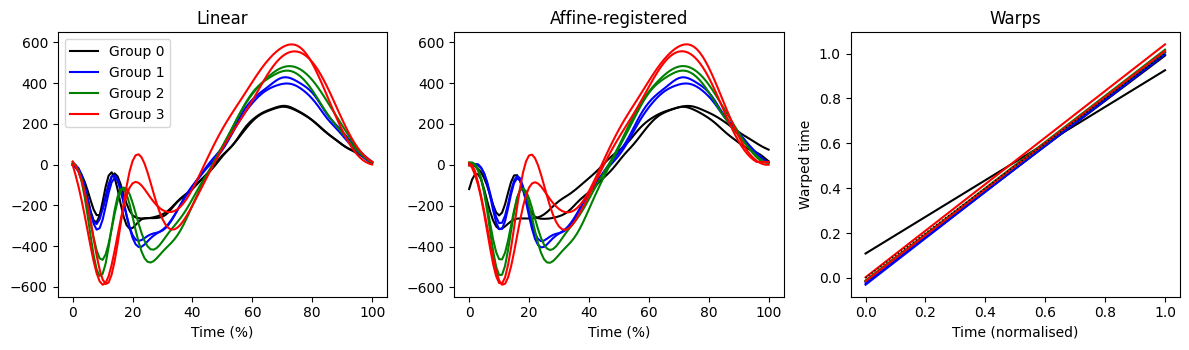

In [3]:
colors = ['k','b','g','r']
res_shift  = reg1d.register_shift(yi)
res_affine = reg1d.register_affine(yi)
print('shifts (fraction of stance):', res_shift.info['shift'].round(3))
print('affine (a, b):'); print(res_affine.info['params'].round(3))
res_shift.plot(group=speed, colors=colors, titles=('Linear', 'Shift-registered', 'Warps'))
res_affine.plot(group=speed, colors=colors, titles=('Linear', 'Affine-registered', 'Warps'))
plt.show()

#### End-point effects in affine registration

With the default settings an affine map γ(t) = a t + b with a + b < 1 cuts off the end of an
observation (the registered curve ends at y(a+b) rather than at y(1) ≈ 0), and values needed
from outside the original domain are held at the boundary value (`fill_value='edge'`). For
forces, which vanish outside stance, two options restore physical plausibility:

- `fill_value='zero'`: outside the original domain the force is zero (rather than the edge value);
- `cover=True`: the affine map is constrained to b ≤ 0 and a + b ≥ 1, so that γ([0,1]) ⊇ [0,1]
  and the whole original observation, including both zero ends, is retained. (With `cover=True`
  the warps are not re-centred, because re-centring would re-introduce cut-off ends.)

`fill_value='extrapolate'` (linear extrapolation of the end slopes) is also available.

(a, b) with cover=True:
[[ 1.026 -0.011]
 [ 1.034 -0.02 ]
 [ 1.055 -0.025]
 [ 1.034 -0.014]
 [ 1.046 -0.004]
 [ 1.042 -0.008]
 [ 1.047 -0.008]
 [ 1.075 -0.   ]]


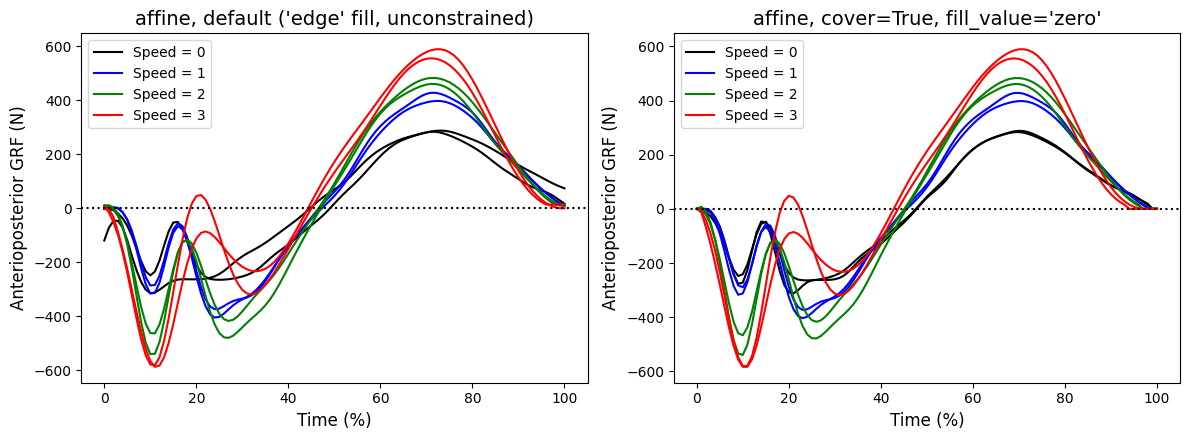

In [4]:
res_affine_cover = reg1d.register_affine(yi, cover=True, fill_value='zero')
print('(a, b) with cover=True:'); print(res_affine_cover.info['params'].round(3))
fig,AX = plt.subplots(1, 2, figsize=(12,4.5))
plot_Dorn2012(res_affine.y, xlabel='Time (%)', title="affine, default ('edge' fill, unconstrained)", ax=AX[0])
plot_Dorn2012(res_affine_cover.y, xlabel='Time (%)', title="affine, cover=True, fill_value='zero'", ax=AX[1])
plt.tight_layout(); plt.show()

## Landmark registration

Landmarks are event times that should coincide after registration. `detect_landmarks` provides a
simple automatic option: the global minimum, the zero crossing adjacent to the global maximum, and
the global maximum. For these data the global **minimum is not a reliable landmark** (the braking
phase has two dips and the deeper one changes between trials), so only the zero crossing and the
maximum are used below. The warp between landmarks is a monotone cubic (PCHIP) interpolant.

landmark times (zero crossing, maximum):
[[0.478 0.7  ]
 [0.474 0.71 ]
 [0.452 0.71 ]
 [0.458 0.71 ]
 [0.468 0.72 ]
 [0.467 0.72 ]
 [0.44  0.73 ]
 [0.47  0.74 ]]
targets: [0.463 0.718]


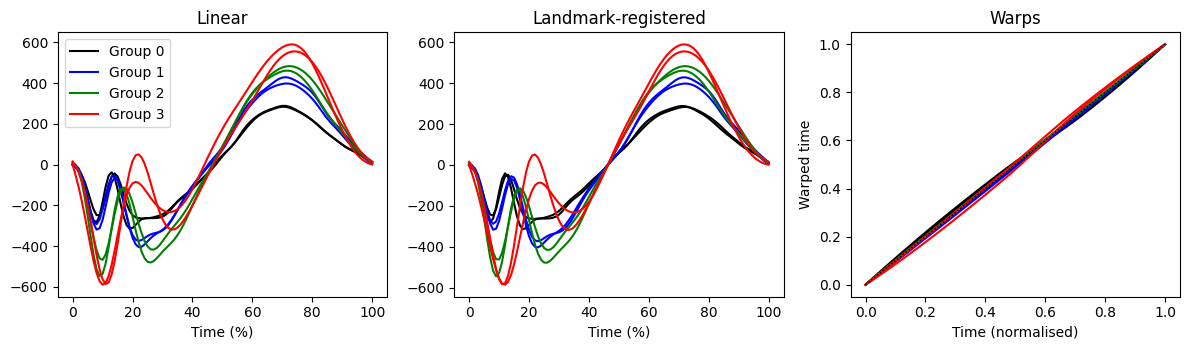

In [5]:
lm = reg1d.landmark.detect_landmarks(yi, kinds=('zero','max'))
print('landmark times (zero crossing, maximum):'); print(lm.round(3))
res_lm = reg1d.register_landmark(yi, kinds=('zero','max'))
print('targets:', res_lm.info['targets'].round(3))
res_lm.plot(group=speed, colors=colors, titles=('Linear', 'Landmark-registered', 'Warps'))
plt.show()

Landmarks may also be supplied explicitly, one row per observation, in normalised time (0–1).
The example below uses the two braking dips found with `scipy.signal.find_peaks` on the negated
signal, plus the propulsive maximum; observations for which the requested number of peaks is not
found are a common failure mode of automatic landmark detection and here would need manual
inspection.

[[0.08 0.23 0.7 ]
 [0.08 0.19 0.71]
 [0.08 0.22 0.71]
 [0.08 0.22 0.71]
 [0.1  0.27 0.72]
 [0.09 0.26 0.72]
 [0.1  0.32 0.73]
 [0.11 0.33 0.74]]


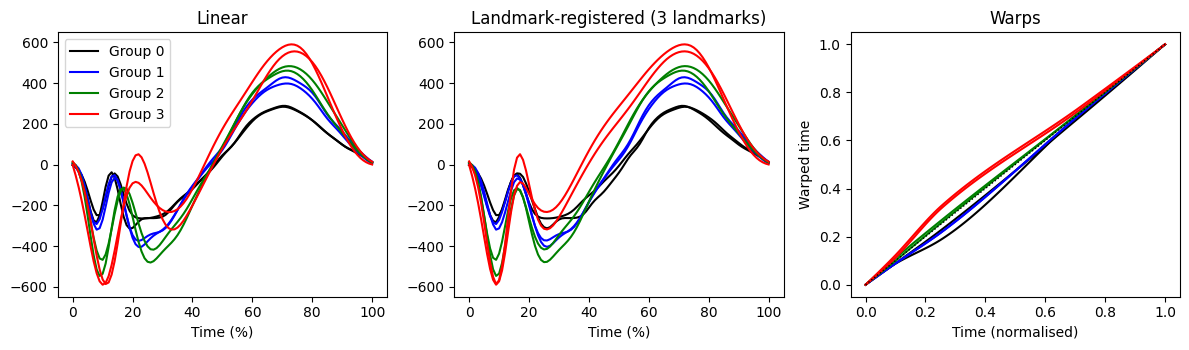

In [6]:
from scipy.signal import find_peaks
lm2 = []
for yy in yi:
    ind,_ = find_peaks(-yy, prominence=20)
    dips  = np.sort(ind[np.argsort(-yy[ind])[::-1][:2]])   # two most negative dips
    lm2.append(np.r_[dips/100, np.argmax(yy)/100])
lm2 = np.array(lm2)
print(lm2.round(2))
res_lm2 = reg1d.register_landmark(yi, landmarks=lm2)
res_lm2.plot(group=speed, colors=colors, titles=('Linear', 'Landmark-registered (3 landmarks)', 'Warps'))
plt.show()

## Dynamic time warping

DTW minimises the accumulated pointwise amplitude difference along a monotone path. Its
strengths are simplicity and speed; its weaknesses for registration are that (i) it compares raw
amplitudes, so observations with different amplitudes (as here: peak GRF roughly doubles across
speeds) are matched by amplitude rather than by shape, producing the characteristic "staircase"
paths, and (ii) the path may run horizontally or vertically, so the warp is not strictly
increasing (flat segments). A Sakoe–Chiba window or a slope-constrained step pattern
(`'strict'`, slopes between 1/2 and 2) mitigates the latter.

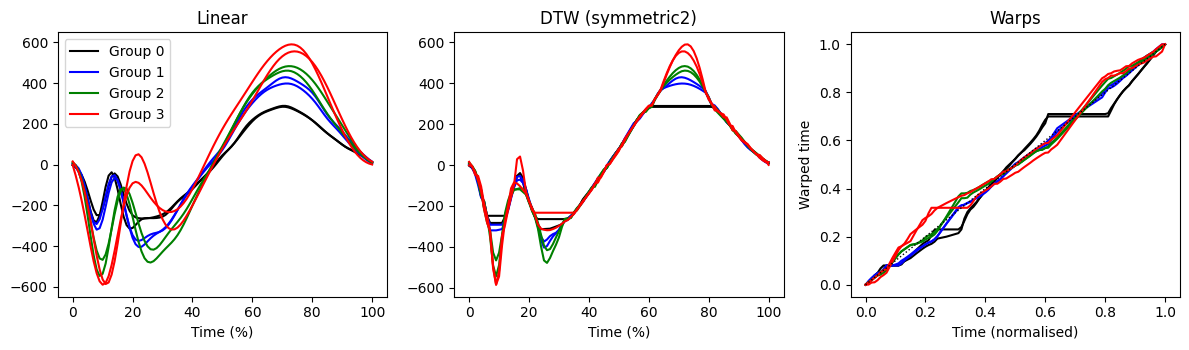

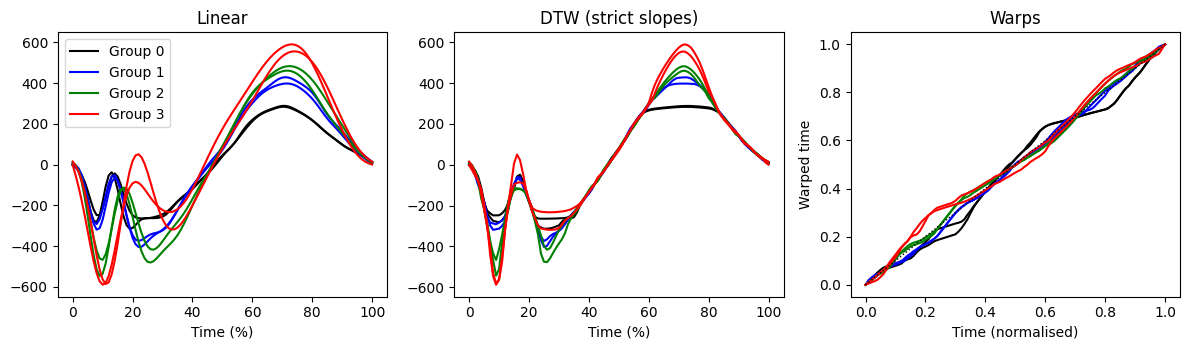

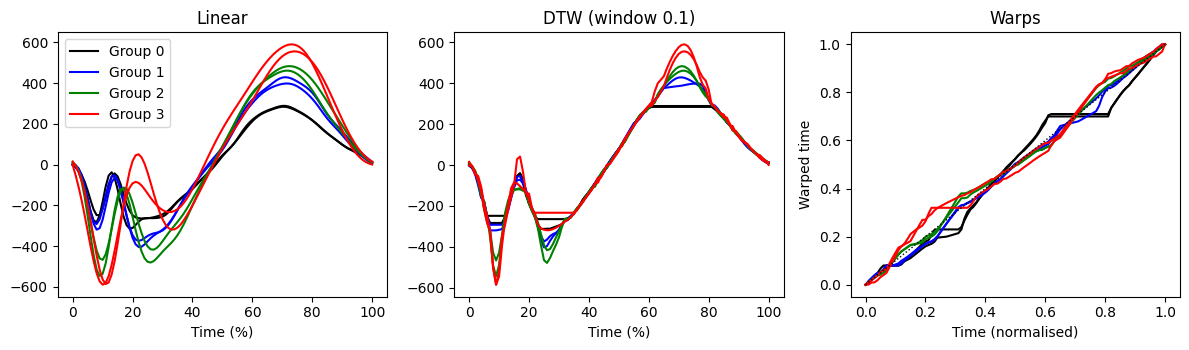

In [7]:
res_dtw  = reg1d.register_dtw(yi)                              # symmetric2, unconstrained
res_dtw2 = reg1d.register_dtw(yi, step_pattern='strict')       # slopes limited to [1/2, 2]
res_dtw3 = reg1d.register_dtw(yi, window=0.1)                  # |gamma(t) - t| <= 0.1
res_dtw.plot(group=speed, colors=colors, titles=('Linear', 'DTW (symmetric2)', 'Warps'))
res_dtw2.plot(group=speed, colors=colors, titles=('Linear', 'DTW (strict slopes)', 'Warps'))
res_dtw3.plot(group=speed, colors=colors, titles=('Linear', 'DTW (window 0.1)', 'Warps'))
plt.show()

#### Smoother, physically plausible DTW warps

Plain DTW produces piecewise paths whose warps have discontinuous slopes (and flat segments),
which is unacceptable for signals such as forces that have smooth first derivatives. Three
remedies are available, separately or combined:

1. **Derivative DTW** (`derivative=True`; Keogh & Pazzani 2001) matches derivative estimates
   instead of values. Matching is then shape-based rather than amplitude-based, which removes
   most of the amplitude-driven staircase matching seen above. The path itself is still piecewise.
2. **Slope-constrained step patterns** (`step_pattern='strict'`, local slopes in [1/2, 2]) forbid
   horizontal and vertical runs, so the warp is strictly increasing.
3. **Warp smoothing** (`smooth=sigma`): the square-root slope √γ′ of each DTW warp is smoothed
   with a Gaussian kernel (width `sigma` in normalised time) and re-integrated. Because √γ′ ≥ 0,
   the result is always a valid, strictly increasing warp with a continuous derivative, and the
   total amount of warping is preserved. The same operation is available as
   `reg1d.warp.smooth_warp` and `Warp1DList.smooth` for any warp.

Note that the smoothing acts on the warp, not on the DTW objective: a smoothed DTW warp is no
longer optimal for the DTW criterion. It is a post-hoc regularisation, analogous to smoothing
a landmark warp; an alternative is to use the DTW warp only to initialise a smooth parametric
refinement (see the continuous method).

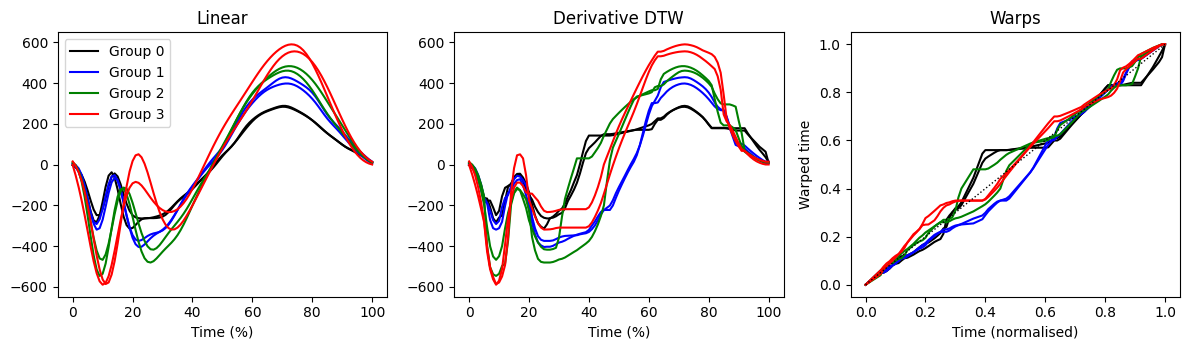

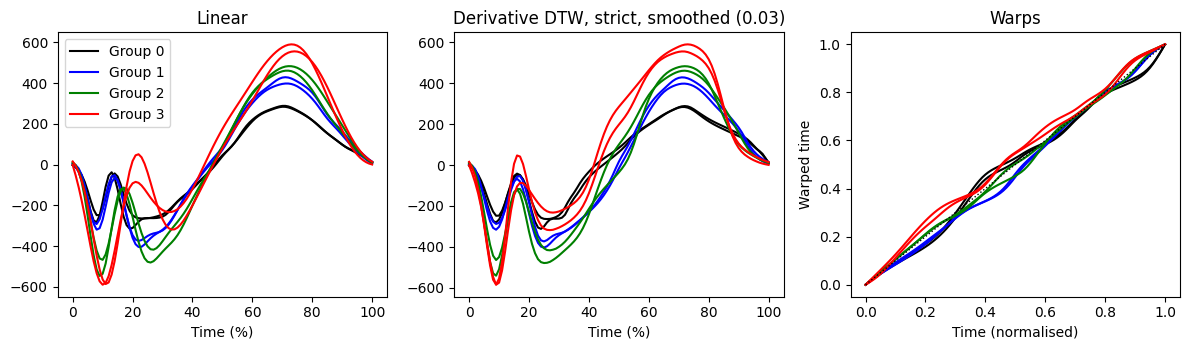

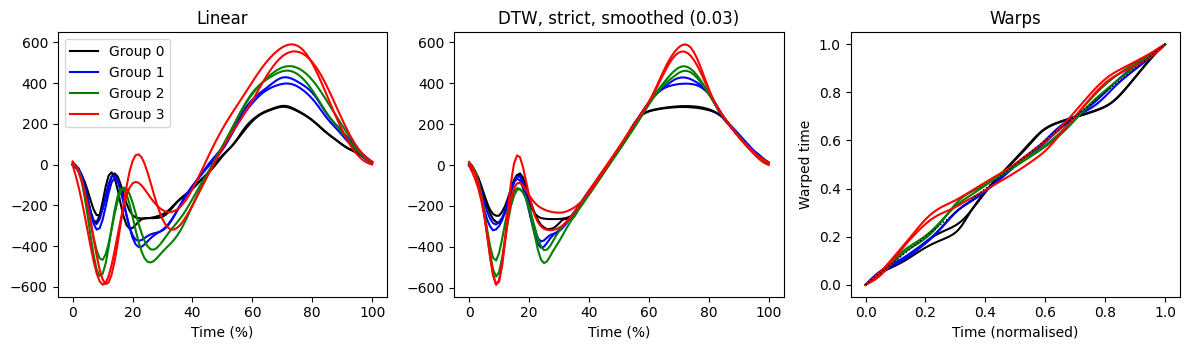

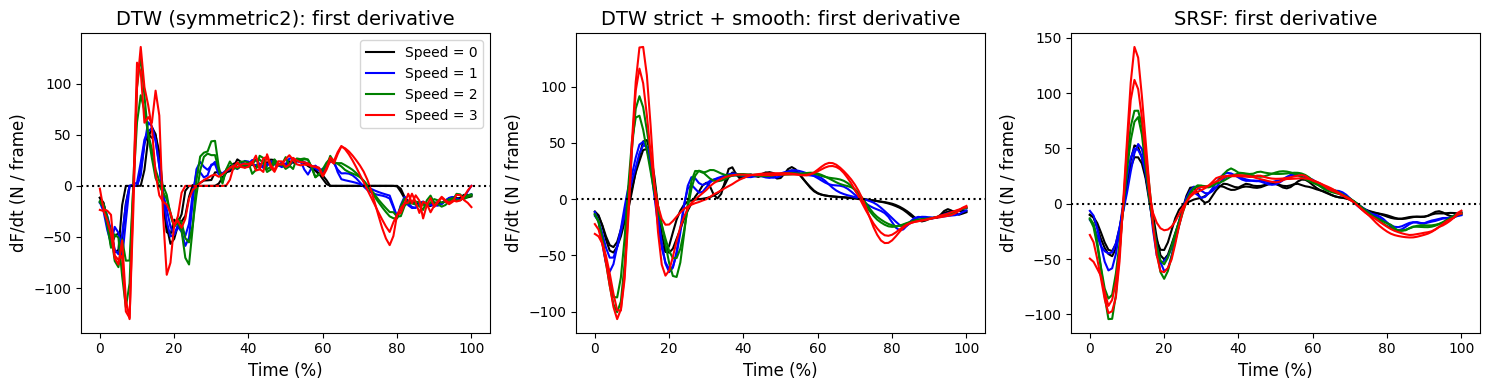

In [8]:
res_ddtw   = reg1d.register_dtw(yi, derivative=True)
res_ddtw_s = reg1d.register_dtw(yi, derivative=True, step_pattern='strict', smooth=0.03)
res_dtw_s  = reg1d.register_dtw(yi, step_pattern='strict', smooth=0.03)
res_ddtw.plot(group=speed, colors=colors, titles=('Linear', 'Derivative DTW', 'Warps'))
res_ddtw_s.plot(group=speed, colors=colors, titles=('Linear', 'Derivative DTW, strict, smoothed (0.03)', 'Warps'))
res_dtw_s.plot(group=speed, colors=colors, titles=('Linear', 'DTW, strict, smoothed (0.03)', 'Warps'))
plt.show()

# first derivatives of the registered data: smooth for the smoothed warps
fig,AX = plt.subplots(1, 3, figsize=(15,4))
for ax,(name,r) in zip(AX, [('DTW (symmetric2)', res_dtw), ('DTW strict + smooth', res_dtw_s), ('SRSF', reg1d.register_srsf(yi, max_iter=5))]):
    plot_Dorn2012(np.gradient(r.y, axis=1), xlabel='Time (%)', ylabel='dF/dt (N / frame)', title=name + ': first derivative', ax=ax)
    if ax is not AX[0]: ax.get_legend().remove()
plt.tight_layout(); plt.show()

## Continuous (parametric) registration

Following Ramsay & Li (1998), the warp is γ(t) = ∫₀ᵗ exp(W) / ∫₀¹ exp(W) with W expanded in a
few sine functions, and the coefficients are fitted by penalised least squares to the
cross-sectional mean. The warps are very smooth and have few degrees of freedom, which is
attractive when timing differences are gradual; they cannot follow sharp local features such
as the double braking dip.

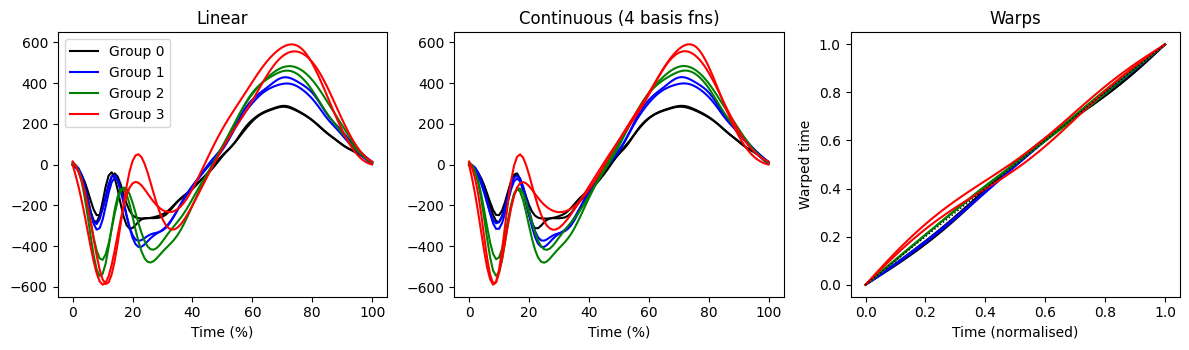

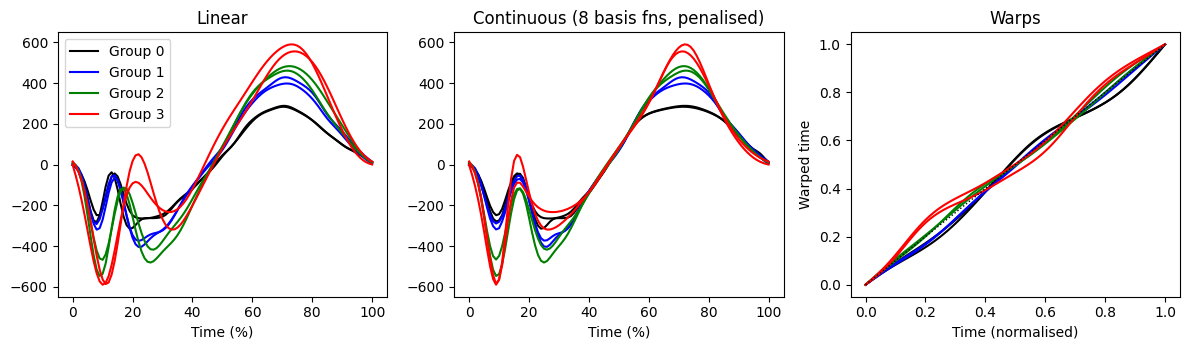

In [9]:
res_c4 = reg1d.register_continuous(yi, n_basis=4)
res_c8 = reg1d.register_continuous(yi, n_basis=8, lam=1e-3)
res_c4.plot(group=speed, colors=colors, titles=('Linear', 'Continuous (4 basis fns)', 'Warps'))
res_c8.plot(group=speed, colors=colors, titles=('Linear', 'Continuous (8 basis fns, penalised)', 'Warps'))
plt.show()

## Self-modelling (shape-invariant model) registration

`register_sim` fits y_i = a_i μ(γ_i) + b_i (Kneip & Gasser 1988; Gervini & Gasser 2004): a common
shape function μ, per-observation amplitude scale and offset, and smooth parametric warps.
Modelling amplitude explicitly is attractive for these data, where peak force roughly doubles
across speeds.

amplitude (a, b) per observation:
[[  0.69 -11.41]
 [  0.72 -21.51]
 [  0.97   7.22]
 [  0.95  -8.04]
 [  1.14  -0.26]
 [  1.2  -35.72]
 [  1.19  48.94]
 [  1.16  53.07]]


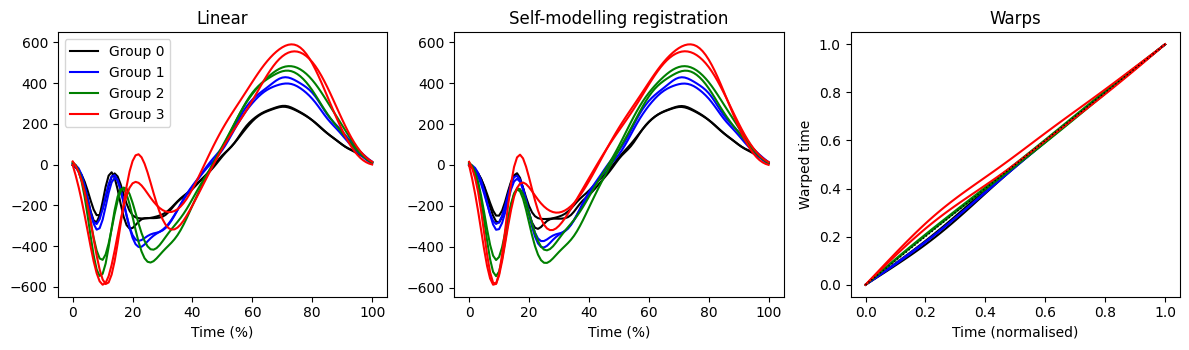

In [10]:
res_sim = reg1d.register_sim(yi, n_basis=6)
print('amplitude (a, b) per observation:'); print(res_sim.info['amplitude'].round(2))
res_sim.plot(group=speed, colors=colors, titles=('Linear', 'Self-modelling registration', 'Warps'))
plt.show()

## Pairwise synchronisation

`register_pairwise` (Tang & Müller 2008) aligns every pair of observations and takes each
observation's warp as the Karcher mean of its warps to all others. It needs no template, at the
cost of J(J−1)/2 pairwise alignments (here with the SRSF engine).

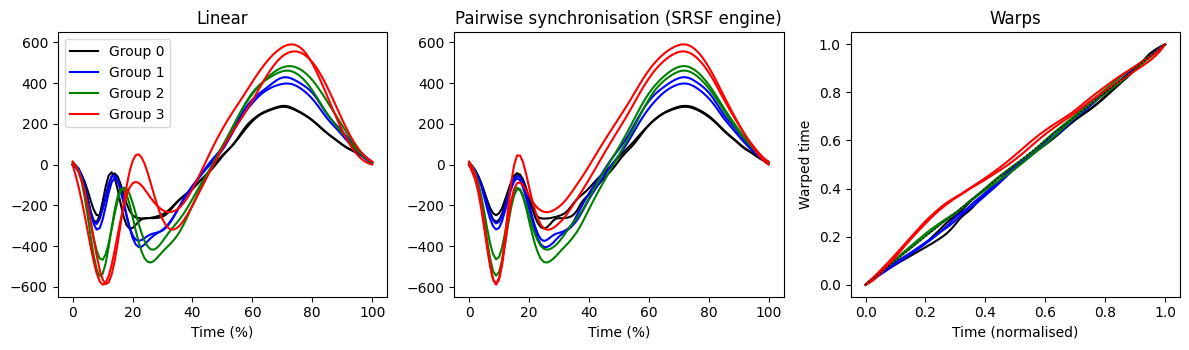

In [11]:
res_pw = reg1d.register_pairwise(yi, engine='srsf')
res_pw.plot(group=speed, colors=colors, titles=('Linear', 'Pairwise synchronisation (SRSF engine)', 'Warps'))
plt.show()

## Elastic (SRSF) registration

The SRSF approach compares *slopes* rather than amplitudes, is invariant to the amplitude scaling
that dominates these data, and yields proper diffeomorphic warps. It is the method used in the
`nlreg1d` paper and is the recommended default.

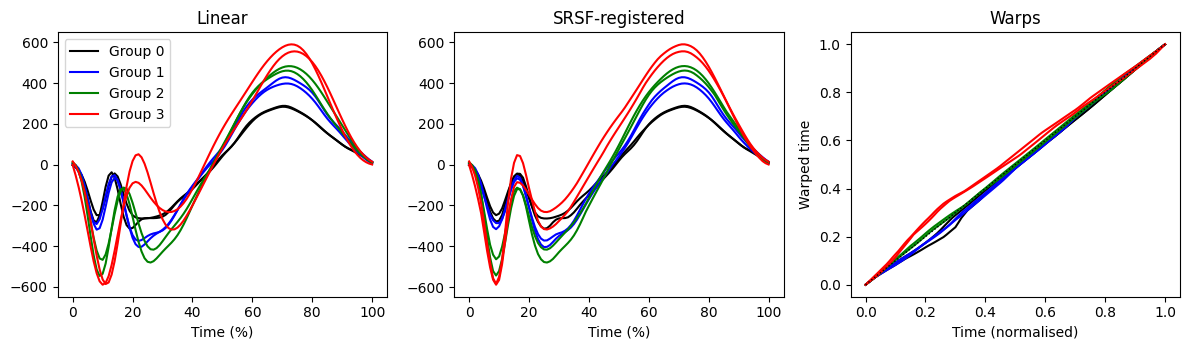

In [12]:
res_srsf = reg1d.register_srsf(yi, max_iter=5)
res_srsf.plot(group=speed, colors=colors, titles=('Linear', 'SRSF-registered', 'Warps'))
plt.show()

## Side-by-side comparison

Two simple descriptive quantities are tabulated for each method: the residual sum of squares about
the cross-sectional mean (an amplitude-dominated criterion that favours DTW, which is allowed to
match amplitudes directly) and the standard deviation (in % stance) of the time of the propulsive
peak (the global maximum).

In [13]:
results = {
    'linear only' : None,
    'shift'       : res_shift,
    'affine'      : res_affine,
    'landmark'    : res_lm,
    'dtw'         : res_dtw,
    'dtw (strict)': res_dtw2,
    'ddtw+smooth' : res_ddtw_s,
    'continuous'  : res_c8,
    'sim'         : res_sim,
    'pairwise'    : res_pw,
    'srsf'        : res_srsf,
}
print(f"{'method':14s} {'SSE about mean':>16s} {'SD of peak time (%)':>22s}")
for name,r in results.items():
    yy  = yi if r is None else r.y
    sse = ((yy - yy.mean(axis=0))**2).sum()
    sd  = np.argmax(yy, axis=1).std()
    print(f"{name:14s} {sse:16.3g} {sd:22.2f}")

method           SSE about mean    SD of peak time (%)
linear only            5.72e+06                   1.20
shift                  5.14e+06                   0.66
affine                 4.91e+06                   0.86
landmark               5.69e+06                   0.43
dtw                    1.43e+06                   4.73
dtw (strict)           1.77e+06                   0.87
ddtw+smooth            5.44e+06                   0.60
continuous             2.52e+06                   0.48
sim                    4.36e+06                   0.93
pairwise               4.42e+06                   0.33
srsf                    4.6e+06                   0.48


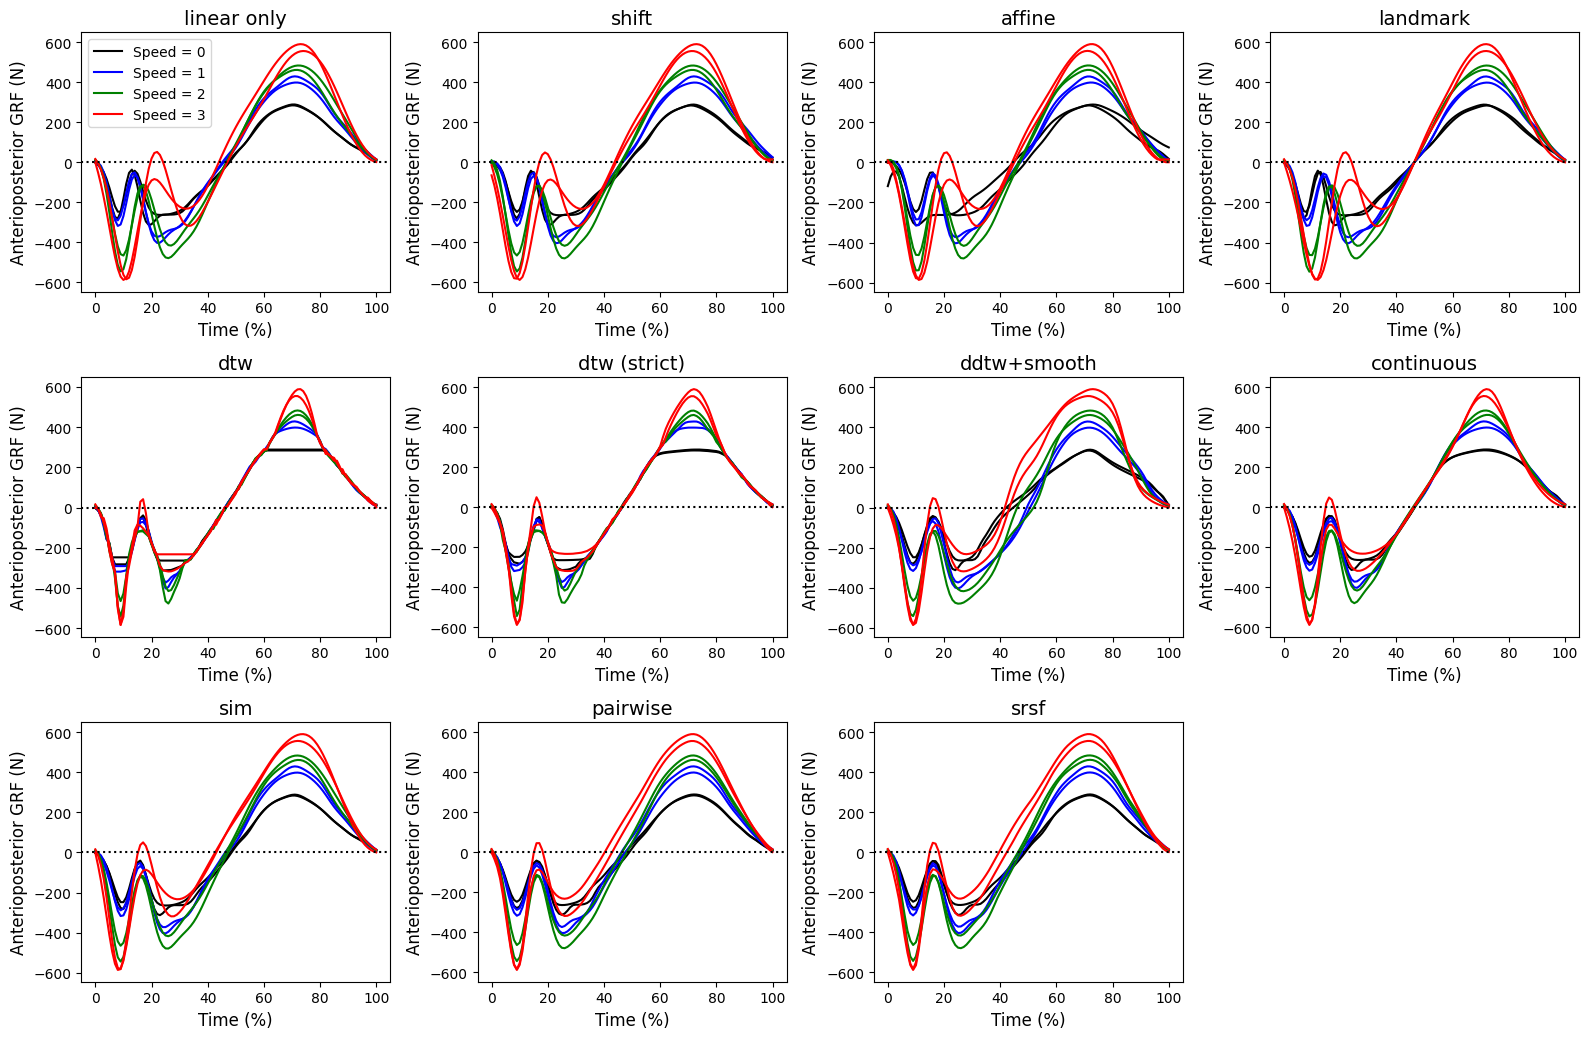

In [14]:
fig,AX = plt.subplots(3, 4, figsize=(16,10.5))
for ax,(name,r) in zip(AX.ravel(), results.items()):
    yy = yi if r is None else r.y
    plot_Dorn2012(yy, xlabel='Time (%)', title=name, ax=ax)
    if ax is not AX[0,0]:
        ax.get_legend().remove()
for ax in AX.ravel()[len(results):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Summary of suitability for the Dorn2012 dataset

- **SRSF** (`register_srsf`): the most appropriate general-purpose method for these data; aligns
  the propulsive peak and zero crossing well and does a reasonable job on the double braking dip.
- **Landmark**: excellent where the landmarks are reliable (zero crossing, maximum) and it is the
  only method that guarantees a chosen event is aligned exactly; automatic landmark detection is
  fragile for the braking dips.
- **DTW**: fast, but amplitude-driven; produces staircase warps on these data unless constrained,
  and its warps are not diffeomorphisms. Derivative DTW with a slope-constrained step pattern and
  warp smoothing gives physically plausible warps and a good alignment of the propulsive peak.
- **Self-modelling**: handles the amplitude differences explicitly; smooth warps; good alignment
  of the main features, with the same local-minimum caveat as the continuous method.
- **Pairwise synchronisation**: results close to SRSF (same engine) without a template.
- **Continuous**: produces smooth, low-dimensional warps; reasonable for the gradual speed-related
  timing shift but cannot resolve the braking dips.
- **Shift / affine**: correct only global offsets; of limited value for these data, but useful as a
  baseline or a first stage before nonlinear registration.